# Chapter 19: Differential Geometry of Surfaces

Source orientation: H. S. M. Coxeter, *Introduction to Geometry*, Chapter 19, printed pages 342-365, PDF pages 360-383. The PDF span was inspected from temporary page renders because the scan has no usable text layer. No source page image, crop, or textbook figure is used here.

## Chapter Goal

Build the local measurement kit for a smooth surface: a two-parameter patch, tangent directions, the first and second fundamental forms, normal curvature, principal curvatures and directions, umbilics, Dupin's theorem, Liouville's theorem, and Dupin's indicatrix.

## Computational Translation Guide

| Book language | Computational object | Inspection target |
| --- | --- | --- |
| $\mathbf r(u^1,u^2)$ | sampled parametric surface | parameter net and tangent frame |
| $g_{ij}=\mathbf r_i\cdot\mathbf r_j$ | metric matrix $G$ | lengths, angles, and $\sqrt{\det G}$ |
| $\mathbf{t}=a^i\mathbf r_i$ | coefficient vector normalized by $a^TGa=1$ | contravariant and covariant components |
| $b_{ij}=\mathbf r_{ij}\cdot\mathbf{n}$ | second fundamental form $B$ | normal curvature quotient $(a^TBa)/(a^TGa)$ |
| principal data | generalized eigenproblem $Ba=\kappa Ga$ | extremal curvatures and $G$-orthogonal directions |
| umbilic | shape operator is scalar | no preferred principal direction |
| Dupin/Liouville | orthogonal-system and inversion checks | curvature lines and sphere preservation |
| Dupin indicatrix | conic $b_{11}x^2+2b_{12}xy+b_{22}y^2=\pm1$ | conic type and curvature radius |

The chapter is local in spirit. A complicated surface is replaced, near one point, by the data carried by its tangent plane and by the first non-flat correction to that plane. The first fundamental form tells how the surface measures tangent vectors. The second fundamental form tells how the surface bends away from its tangent plane. Most of the chapter can be read as the interaction of these two quadratic forms.

The notebook keeps the chapter's tensor notation visible, but it uses small matrices whenever possible. A learner should be able to point to a line of code and identify the corresponding geometric claim: `G` measures lengths and angles, `B` measures normal bending, `solve(G, B)` builds the shape operator, and an eigenvector of that operator is a principal direction.



In [1]:
from __future__ import annotations
from pathlib import Path
import json, math, sys

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
import trimesh
from IPython.display import Markdown, display


def find_book_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents, here / "Introduction-to-Geometry"]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
    raise FileNotFoundError("Introduction-to-Geometry book root not found")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, assert_artifacts, book_relative, display_artifact, ensure_chapter_artifact_dirs, write_csv, write_json

CHAPTER_NO = 19
ensure_chapter_artifact_dirs(CHAPTER_NO, BOOK_ROOT)
plt.rcParams.update({"figure.dpi": 140, "savefig.dpi": 180, "font.size": 10})

STALE_ARTIFACTS = [
    artifact_path(CHAPTER_NO, "figures", "concept_configuration.svg", BOOK_ROOT),
    artifact_path(CHAPTER_NO, "figures", "parameter_experiment.svg", BOOK_ROOT),
    artifact_path(CHAPTER_NO, "checks", "visual_summary.json", BOOK_ROOT),
]
for stale in STALE_ARTIFACTS:
    if stale.exists():
        stale.unlink()

source_span = {
    "chapter": 19,
    "printed_pages": "342-365",
    "pdf_pages": "360-383",
    "inspection_method": "Temporary private renders of scanned PDF pages; no source images used as artifacts.",
    "sections": ["19.1 two parameters", "19.2 directions", "19.3 normal curvature", "19.4 principal curvatures", "19.5 principal directions", "19.6 umbilics", "19.7 Dupin and Liouville", "19.8 Dupin indicatrix"],
}
source_span_path = write_json(artifact_path(CHAPTER_NO, "checks", "source-span.json", BOOK_ROOT), source_span)
storyboard = {
    "goal": "Visualization-first local surface geometry using metrics, curvature forms, theorem checks, and indicatrix conics.",
    "visuals": [
        "two-parameter-surface-patch.html",
        "tangent-plane-components.png",
        "normal-curvature-principal-directions.png",
        "gaussian-curvature-sign-classification.png",
        "umbilic-surface-of-revolution-curvatures.png",
        "dupin-orthogonal-surface-systems.html",
        "liouville-inversion-plane-to-sphere.html",
        "dupin-liouville-proof-map.png",
        "dupin-indicatrix-conics.png",
    ],
    "libraries": {"Plotly": "interactive 3D surface views", "Matplotlib": "static concept and proof figures", "SymPy": "exact metric identities", "Trimesh": "mesh area sanity", "NetworkX": "proof dependency DAG"},
}
storyboard_path = write_json(artifact_path(CHAPTER_NO, "checks", "visual-storyboard.json", BOOK_ROOT), storyboard)
display(Markdown(f"Book root: `{BOOK_ROOT}`"))
display(Markdown(f"Source span ledger: `{book_relative(source_span_path, BOOK_ROOT)}`"))


Book root: `D:\Geometry\Introduction-to-Geometry`

Source span ledger: `artifacts/chapter-19/checks/source-span.json`

## 1. Two-Parameter Surface Patches

A regular surface patch has two independent parameter directions. On the unit sphere, colatitude and longitude make the equations simple, but the longitude direction collapses at the poles. Away from those singular chart points, $\mathbf r_u$ and $\mathbf r_v$ span the tangent plane and $\sqrt{\det G}=|\mathbf r_u\times\mathbf r_v|$ is the area scale.

The sphere calculation also shows why parameter choices matter. In Monge form, one hemisphere can be written as a graph, but the square root hides the symmetry and fails across the equator. Colatitude and longitude expose the natural curve families instead. The metric immediately warns us about the poles: $g_{22}=\sin^2 u$ vanishes there, so the longitude direction is no longer an independent tangent direction. That is a chart failure, not a failure of the sphere.



In [2]:
u, v = sp.symbols("u v", positive=True, real=True)
r = sp.Matrix([sp.sin(u)*sp.cos(v), sp.sin(u)*sp.sin(v), sp.cos(u)])
ru, rv = r.diff(u), r.diff(v)
G_sphere = sp.Matrix([[ru.dot(ru), ru.dot(rv)], [rv.dot(ru), rv.dot(rv)]])
g_det = sp.simplify(G_sphere.det())
area = sp.integrate(sp.integrate(sp.sqrt(g_det), (v, 0, 2*sp.pi)), (u, 0, sp.pi))
assert sp.simplify(G_sphere - sp.diag(1, sp.sin(u)**2)) == sp.zeros(2)
assert sp.simplify(area - 4*sp.pi) == 0

def sphere_patch(U, V):
    return np.sin(U)*np.cos(V), np.sin(U)*np.sin(V), np.cos(U)

def grid_faces(rows, cols):
    faces=[]
    for i in range(rows-1):
        for j in range(cols-1):
            a=i*cols+j; faces += [[a,a+1,a+cols],[a+1,a+cols+1,a+cols]]
    return np.array(faces)

U,V=np.meshgrid(np.linspace(0.35,2.25,58),np.linspace(-0.85,2.35,76),indexing="ij")
X,Y,Z=sphere_patch(U,V)
mesh=trimesh.Trimesh(vertices=np.c_[X.ravel(),Y.ravel(),Z.ravel()],faces=grid_faces(*U.shape),process=False)
u0,v0=1.05,0.8
p=np.array([math.sin(u0)*math.cos(v0),math.sin(u0)*math.sin(v0),math.cos(u0)])
ru0=np.array([math.cos(u0)*math.cos(v0),math.cos(u0)*math.sin(v0),-math.sin(u0)])
rv0=np.array([-math.sin(u0)*math.sin(v0),math.sin(u0)*math.cos(v0),0.0])
n0=np.cross(ru0,rv0); n0=n0/np.linalg.norm(n0)
fig=go.Figure()
fig.add_surface(x=X,y=Y,z=Z,colorscale="Viridis",showscale=False,opacity=.82,name="sphere patch")
for uu in np.linspace(.45,2.15,6):
    vv=np.linspace(-.85,2.35,160); xs,ys,zs=sphere_patch(np.full_like(vv,uu),vv)
    fig.add_trace(go.Scatter3d(x=xs,y=ys,z=zs,mode="lines",line=dict(color="#23395d",width=4),showlegend=False))
for vv0 in np.linspace(-.75,2.25,7):
    uu=np.linspace(.35,2.25,160); xs,ys,zs=sphere_patch(uu,np.full_like(uu,vv0))
    fig.add_trace(go.Scatter3d(x=xs,y=ys,z=zs,mode="lines",line=dict(color="#9a3412",width=3),showlegend=False))
for vec,color,name in [(ru0,"#0f766e","r_u"),(rv0,"#b91c1c","r_v"),(n0,"#1d4ed8","normal")]:
    vec=vec/np.linalg.norm(vec); end=p+.34*vec
    fig.add_trace(go.Scatter3d(x=[p[0],end[0]],y=[p[1],end[1]],z=[p[2],end[2]],mode="lines+markers",line=dict(color=color,width=8),marker=dict(size=3),name=name))
fig.update_layout(title="Two-parameter patch: sphere net and tangent frame",scene=dict(aspectmode="data"),margin=dict(l=0,r=0,t=42,b=0))
patch_html=artifact_path(CHAPTER_NO,"html","two-parameter-surface-patch.html",BOOK_ROOT)
fig.write_html(patch_html,include_plotlyjs="cdn")
sphere_checks={"metric": [[str(x) for x in row] for row in G_sphere.tolist()],"area": str(area),"sqrt_det_at_sample": float(np.linalg.norm(np.cross(ru0,rv0))),"sin_u_sample": float(math.sin(u0)),"mesh_area": float(mesh.area),"exact_patch_area": float((2.35+.85)*(math.cos(.35)-math.cos(2.25))),"mesh_faces": int(len(mesh.faces))}
assert abs(sphere_checks["sqrt_det_at_sample"]-sphere_checks["sin_u_sample"])<1e-12
assert abs(sphere_checks["mesh_area"]-sphere_checks["exact_patch_area"])<.08
display_artifact(patch_html)
sphere_checks


{'metric': [['sin(u)**2 + sin(v)**2*cos(u)**2 + cos(u)**2*cos(v)**2', '0'],
  ['0', 'sin(u)**2*sin(v)**2 + sin(u)**2*cos(v)**2']],
 'area': '4*pi',
 'sqrt_det_at_sample': 0.8674232255940171,
 'sin_u_sample': 0.867423225594017,
 'mesh_area': 5.014809903467325,
 'exact_patch_area': 5.016148273824378,
 'mesh_faces': 8550}

## 2. Directions on a Surface

A tangent direction is $\mathbf{t}=a^1\mathbf{r}_1+a^2\mathbf{r}_2$. The coefficients $a^i$ are contravariant; the metric lowers them to $a_i=g_{ij}a^j$. The figure uses an oblique Monge patch so that the distinction is visible. The ellipse in coefficient space is the condition $a^TGa=1$.

This is the practical reason the chapter spends time on covariant and contravariant components. The numbers attached to a tangent vector depend on the basis used to describe it. If the parameter curves meet obliquely, the visual direction of $\mathbf{t}$ is not read correctly by treating $(a^1,a^2)$ as ordinary Euclidean coordinates. The metric ellipse is the correction: it shows which coefficient pairs represent unit tangent vectors on the actual surface.

Orthogonal trajectories are handled the same way. Two families of curves are perpendicular when their tangent coefficient vectors have zero $G$-inner product. The condition is therefore metric-dependent, which is why the chapter writes it in tensor notation instead of using a Euclidean dot product in the parameter plane.



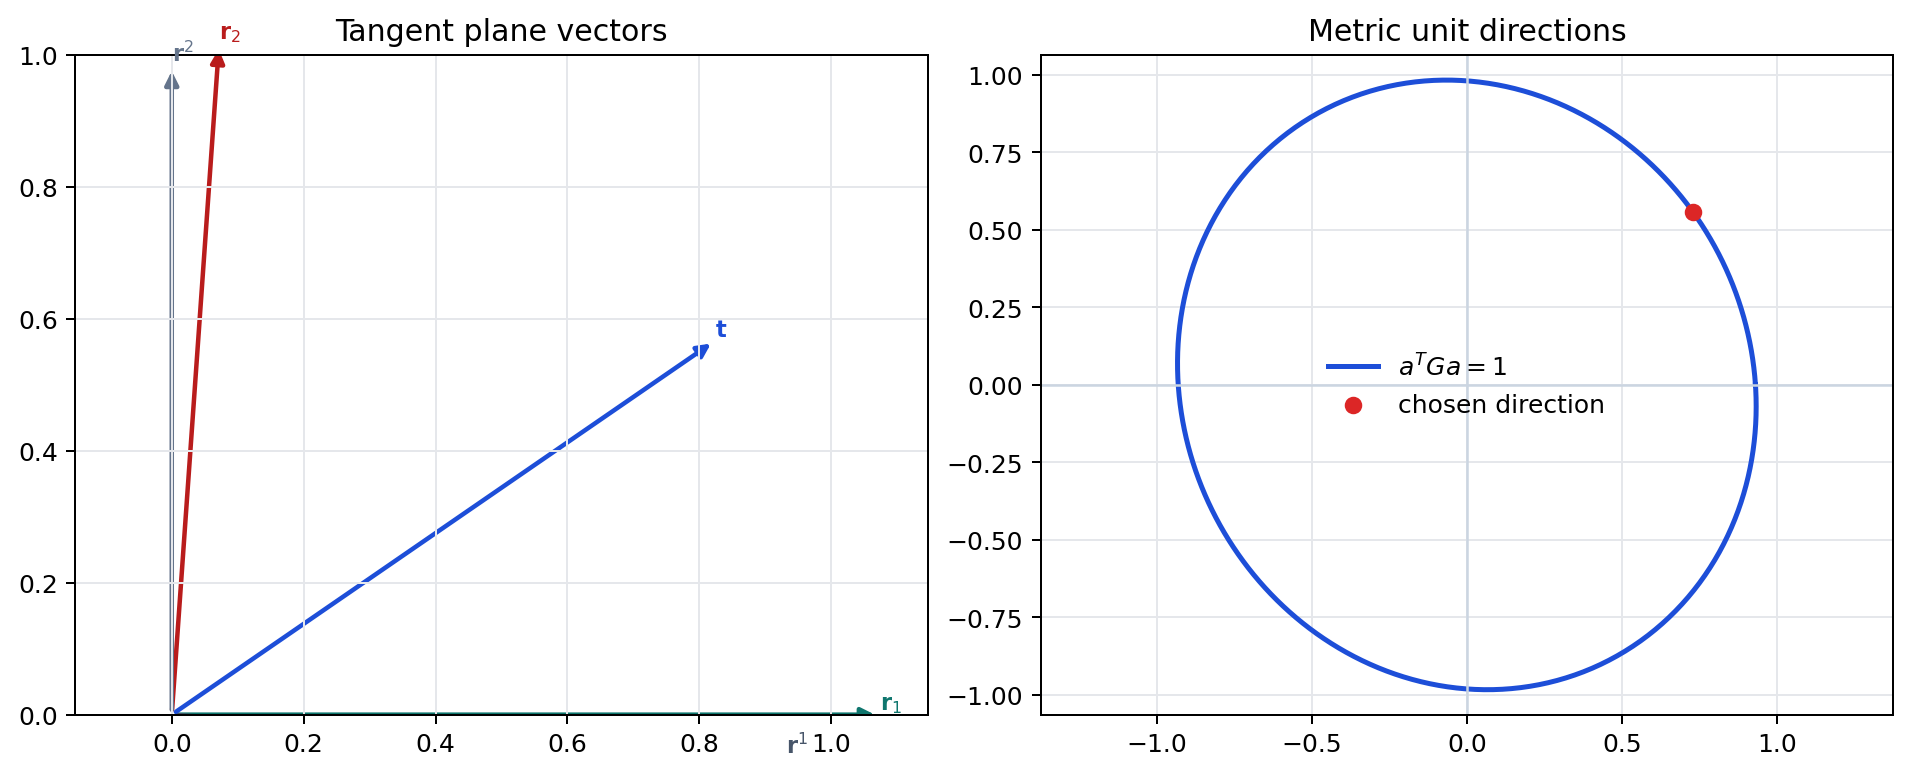

{'G': [[1.152881, 0.07702700000000001], [0.07702700000000001, 1.038809]],
 'G_inverse_residual': 1.1102230246251565e-16,
 'sqrt_det_G': 1.0916455468694957,
 'cross_area': 1.0916455468694954,
 'a_contravariant': [0.7299593964718053, 0.5576078723048513],
 'a_covariant': [0.8845071805438371, 0.6354746586531641],
 'unit_residual': 0.0,
 'dual_pairing_residual': 2.220446049250313e-16}

In [3]:
def graph_data(x,y):
    A,Bc,C,px,py=.28,-.18,.22,.16,-.05
    zx=2*A*x+C*y+px; zy=2*Bc*y+C*x+py
    r1=np.array([1.,0.,zx]); r2=np.array([0.,1.,zy])
    n=np.array([-zx,-zy,1.]); n=n/np.linalg.norm(n)
    G=np.array([[r1@r1,r1@r2],[r2@r1,r2@r2]])
    B=np.array([[2*A,C],[C,2*Bc]])/math.sqrt(1+zx*zx+zy*zy)
    return r1,r2,n,G,B

def principal_data(G,B):
    S=np.linalg.solve(G,B); vals,vecs=np.linalg.eig(S); order=np.argsort(vals.real)
    vals=vals.real[order]; vecs=vecs.real[:,order]
    for j in range(2): vecs[:,j]/=math.sqrt(vecs[:,j]@G@vecs[:,j])
    return S,vals,vecs

def arrow(ax,start,end,color,label):
    ax.add_patch(FancyArrowPatch(start,end,arrowstyle="-|>",mutation_scale=11,linewidth=1.8,color=color))
    ax.text(end[0],end[1],label,color=color,fontsize=9,ha="left",va="bottom")

r1,r2,n,G,B=graph_data(.55,-.35)
Ginv=np.linalg.inv(G); dual=Ginv@np.vstack([r1,r2])
a=np.array([.72,.55]); a=a/math.sqrt(a@G@a); acov=G@a; t=a[0]*r1+a[1]*r2
e1=r1/np.linalg.norm(r1); e2=r2-(r2@e1)*e1; e2=e2/np.linalg.norm(e2)
proj=lambda q: np.array([q@e1,q@e2])
angles=np.linspace(0,2*np.pi,420); raw=np.c_[np.cos(angles),np.sin(angles)]
ellipse=raw/np.sqrt(np.einsum("ij,jk,ik->i",raw,G,raw))[:,None]
fig,axes=plt.subplots(1,2,figsize=(10.5,4.2),constrained_layout=True)
ax=axes[0]
for vec,color,label in [(r1,"#0f766e",r"$\mathbf{r}_1$"),(r2,"#b91c1c",r"$\mathbf{r}_2$"),(dual[0],"#475569",r"$\mathbf{r}^1$"),(dual[1],"#64748b",r"$\mathbf{r}^2$"),(t,"#1d4ed8",r"$\mathbf{t}$")]: arrow(ax,(0,0),proj(vec),color,label)
ax.set_aspect("equal",adjustable="datalim"); ax.grid(True,color="#e5e7eb"); ax.set_title("Tangent plane vectors")
ax=axes[1]; ax.plot(ellipse[:,0],ellipse[:,1],color="#1d4ed8",lw=2,label=r"$a^TGa=1$"); ax.scatter([a[0]],[a[1]],color="#dc2626",zorder=3,label="chosen direction")
ax.axhline(0,color="#cbd5e1",lw=1); ax.axvline(0,color="#cbd5e1",lw=1); ax.set_aspect("equal",adjustable="datalim"); ax.grid(True,color="#e5e7eb"); ax.set_title("Metric unit directions"); ax.legend(frameon=False)
components_png=artifact_path(CHAPTER_NO,"figures","tangent-plane-components.png",BOOK_ROOT)
fig.savefig(components_png,bbox_inches="tight"); plt.close(fig)
metric_checks={"G":G.tolist(),"G_inverse_residual":float(np.max(np.abs(G@Ginv-np.eye(2)))),"sqrt_det_G":float(math.sqrt(np.linalg.det(G))),"cross_area":float(np.linalg.norm(np.cross(r1,r2))),"a_contravariant":a.tolist(),"a_covariant":acov.tolist(),"unit_residual":float(abs(a@G@a-1)),"dual_pairing_residual":float(np.max(np.abs(np.array([[dual[i]@[r1,r2][j] for j in range(2)] for i in range(2)])-np.eye(2))))}
assert metric_checks["G_inverse_residual"]<1e-12 and metric_checks["unit_residual"]<1e-12
assert abs(metric_checks["sqrt_det_G"]-metric_checks["cross_area"])<1e-12
assert metric_checks["dual_pairing_residual"]<1e-12
display_artifact(components_png,width=900)
metric_checks


## 3. Normal Curvature, Principal Curvatures, and Principal Directions

For a unit tangent direction, normal curvature is the Rayleigh quotient $\kappa=(a^TBa)/(a^TGa)$. The maximum and minimum values are the generalized eigenvalues of $B a=\kappa G a$. Their directions are perpendicular with respect to the surface metric.

The normal curvature scan is a numerical version of rotating a normal plane through the fixed normal line. Each angle chooses a tangent direction, hence a normal section curve. The quotient $a^TBa/a^TGa$ returns the signed curvature of that section in the chosen normal direction. The extrema are forced by linear algebra: stationary values of a quotient of two quadratic forms are generalized eigenvalues.

This same cell is also a scaffold for Rodrigues' formula. Along a principal direction, the derivative of the normal is parallel to the displacement vector, with scale $-\kappa$. In matrix language, the direction is an eigenvector of the shape operator. Away from principal directions, the normal derivative usually has components in both tangent basis directions.



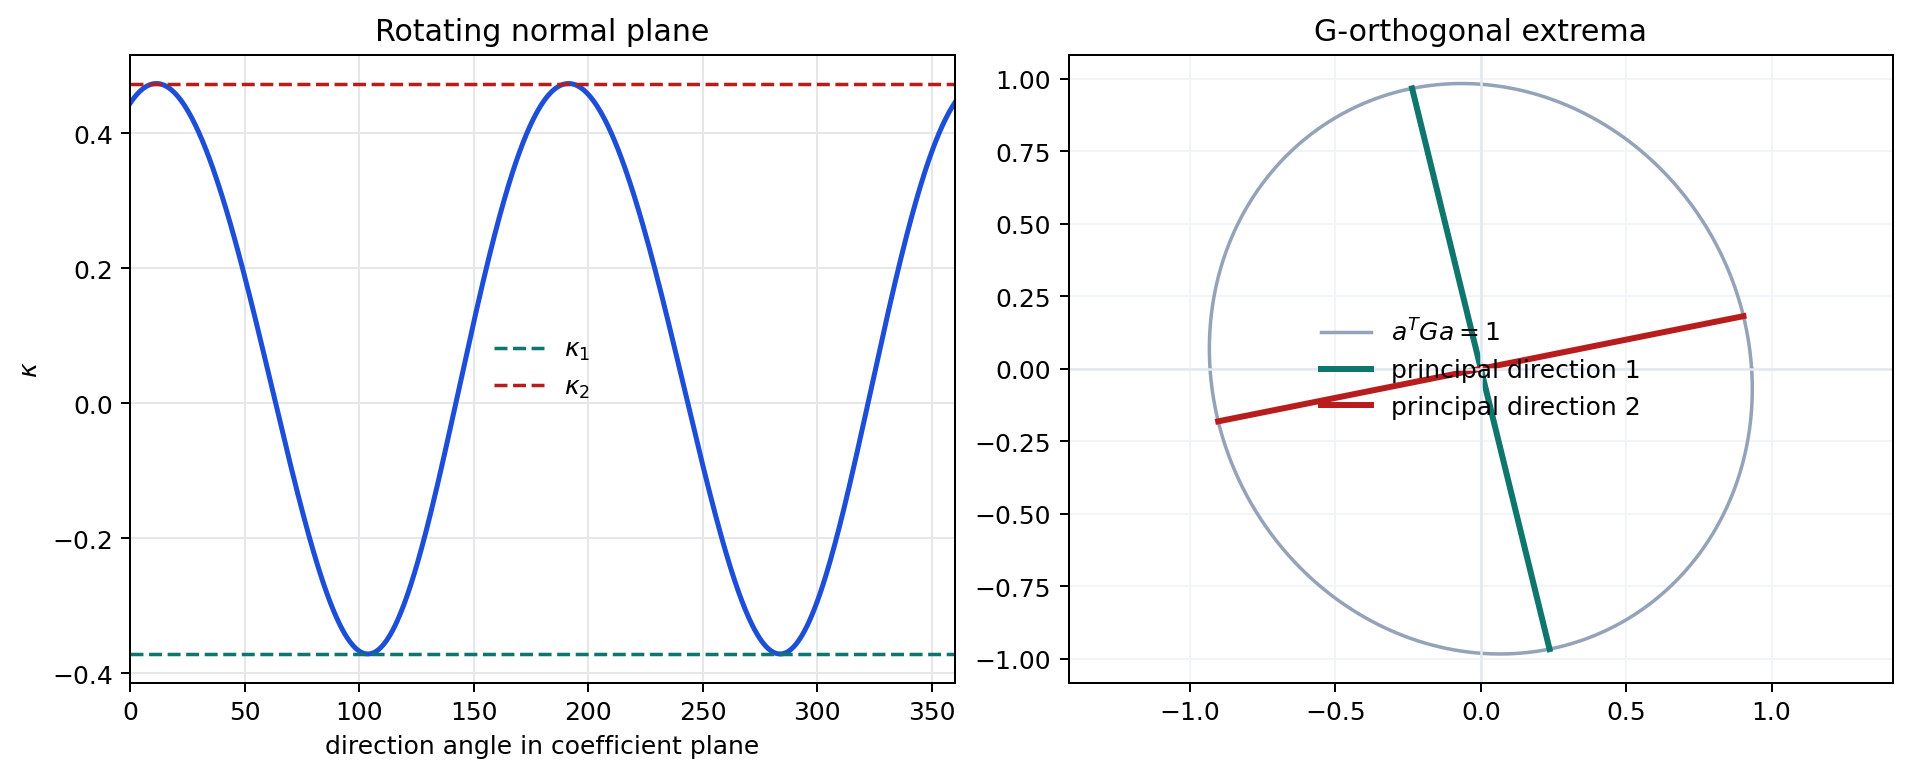

{'B': [[0.5129870236780686, 0.20153061644495548],
  [0.20153061644495548, -0.3297773723644726]],
 'shape_operator': [[0.43415002079994397, 0.19699215383168944],
  [0.16180967126083637, -0.33206401465299784]],
 'principal_curvatures': [-0.37162261261313595, 0.4737086187600821],
 'H': 0.051043003073473064,
 'K': -0.1760408345209817,
 'trace_residual': 0.0,
 'det_residual': 2.7755575615628914e-17,
 'eigen_residuals': [0.0, 5.721958498152797e-17],
 'G_orthogonality_residual': 8.326672684688674e-17,
 'scan_min_max': [-0.3716055720605158, 0.47370395392730585]}

In [4]:
S,kvals,kdirs=principal_data(G,B)
theta=np.linspace(0,2*np.pi,721); dirs=np.c_[np.cos(theta),np.sin(theta)]
kappa=np.array([(q@B@q)/(q@G@q) for q in dirs])
unit_dirs=dirs/np.sqrt(np.einsum("ij,jk,ik->i",dirs,G,dirs))[:,None]
eig_res=[float(np.linalg.norm(B@kdirs[:,j]-kvals[j]*G@kdirs[:,j])) for j in range(2)]
gortho=float(abs(kdirs[:,0]@G@kdirs[:,1]))
fig,axes=plt.subplots(1,2,figsize=(10.5,4.2),constrained_layout=True)
ax=axes[0]; ax.plot(np.degrees(theta),kappa,color="#1d4ed8",lw=2)
for val,color,label in [(kvals[0],"#0f766e",r"$\kappa_1$"),(kvals[1],"#b91c1c",r"$\kappa_2$")]: ax.axhline(val,color=color,ls="--",lw=1.4,label=label)
ax.set_xlim(0,360); ax.set_xlabel("direction angle in coefficient plane"); ax.set_ylabel(r"$\kappa$"); ax.set_title("Rotating normal plane"); ax.grid(True,color="#e5e7eb"); ax.legend(frameon=False)
ax=axes[1]; ax.plot(unit_dirs[:,0],unit_dirs[:,1],color="#94a3b8",lw=1.4,label=r"$a^TGa=1$")
for j,color in enumerate(["#0f766e","#b91c1c"]):
    d=kdirs[:,j]; ax.plot([-d[0],d[0]],[-d[1],d[1]],color=color,lw=2.4,label=f"principal direction {j+1}")
ax.axhline(0,color="#e2e8f0",lw=1); ax.axvline(0,color="#e2e8f0",lw=1); ax.set_aspect("equal",adjustable="datalim"); ax.grid(True,color="#f1f5f9"); ax.legend(frameon=False); ax.set_title("G-orthogonal extrema")
principal_png=artifact_path(CHAPTER_NO,"figures","normal-curvature-principal-directions.png",BOOK_ROOT)
fig.savefig(principal_png,bbox_inches="tight"); plt.close(fig)
principal_checks={"B":B.tolist(),"shape_operator":S.tolist(),"principal_curvatures":kvals.tolist(),"H":float(np.trace(S)/2),"K":float(np.linalg.det(S)),"trace_residual":float(abs(np.trace(S)-np.sum(kvals))),"det_residual":float(abs(np.linalg.det(S)-np.prod(kvals))),"eigen_residuals":eig_res,"G_orthogonality_residual":gortho,"scan_min_max":[float(kappa.min()),float(kappa.max())]}
assert max(eig_res)<1e-12 and gortho<1e-12 and principal_checks["det_residual"]<1e-12
display_artifact(principal_png,width=900)
principal_checks


## 4. Gaussian Curvature Sign and Umbilics

The product $K=\kappa_1\kappa_2=\det(B)/\det(G)$ distinguishes local shape. Positive $K$ gives a synclastic oval point, zero $K$ gives parabolic or developable behavior, and negative $K$ gives an anticlastic saddle. An umbilic is different: the two principal curvatures coincide, so the point loses a preferred principal direction.

The sign of $K$ is stronger than a visual label. If both principal curvatures have the same sign, every normal section bends to the same side of the tangent plane. If their product is negative, some normal sections bend one way and others bend the opposite way, so the surface crosses its tangent plane in two distinguished inflectional directions. If the product is zero, at least one normal curvature vanishes. Cylinders and cones are the standard developable examples, but the local parabolic cylinder panel is enough to see the determinant condition.

The umbilic plot should be read separately from the sign classification. A point can have positive Gaussian curvature without being umbilic. Umbilicity asks for equality of the two principal curvatures, not merely equality of sign. The sphere panel is the limiting case in which every point passes that equality test.



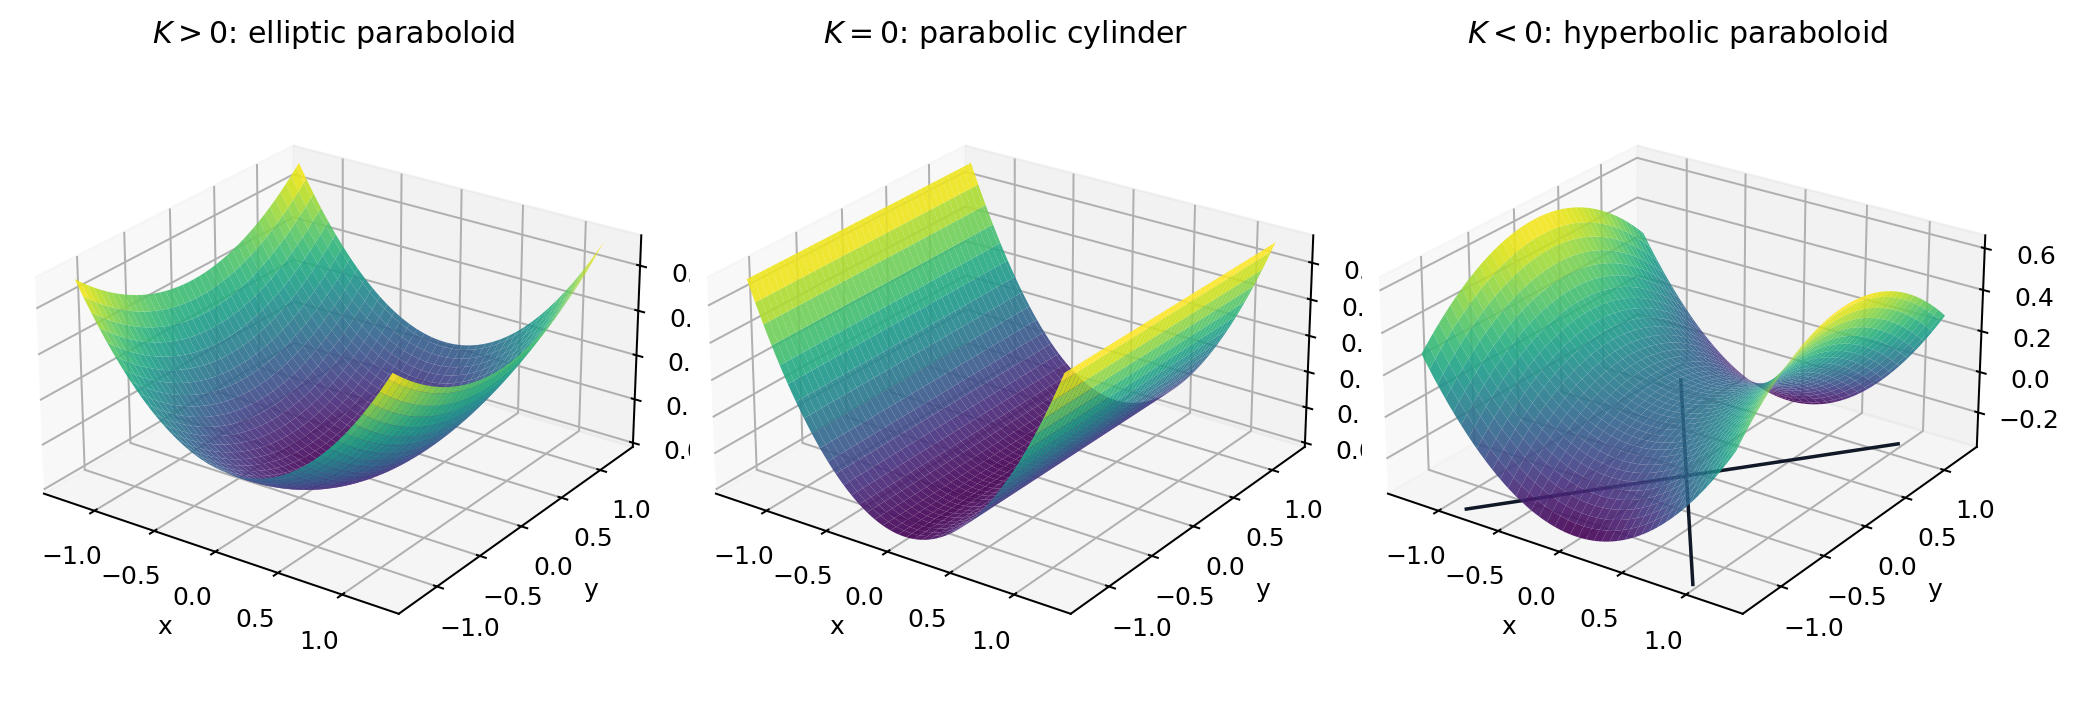

,surface_model,G_at_origin,B_at_origin,kappa_1,kappa_2,H,K,chapter_language
0,synclastic,"[[1, 0], [0, 1]]","[[0.82, 0.0], [0.0, 0.35]]",0.35,0.82,0.585,0.287,synclastic
1,parabolic,"[[1, 0], [0, 1]]","[[0.72, 0.0], [0.0, 0.0]]",0.00,0.72,0.360,0.000,parabolic/developable
2,anticlastic,"[[1, 0], [0, 1]]","[[0.82, 0.0], [0.0, -0.45]]",-0.45,0.82,0.185,-0.369,anticlastic


In [5]:
cases=[("synclastic",np.array([[.82,0.],[0.,.35]]),"$K>0$: elliptic paraboloid"),("parabolic",np.array([[.72,0.],[0.,0.]]),"$K=0$: parabolic cylinder"),("anticlastic",np.array([[.82,0.],[0.,-.45]]),"$K<0$: hyperbolic paraboloid")]
xx=np.linspace(-1.25,1.25,80); yy=np.linspace(-1.25,1.25,80); XX,YY=np.meshgrid(xx,yy)
fig=plt.figure(figsize=(11.2,3.8),constrained_layout=True); rows=[]
for i,(name,Q,title) in enumerate(cases,1):
    ZZ=.5*(Q[0,0]*XX**2+2*Q[0,1]*XX*YY+Q[1,1]*YY**2)
    ax=fig.add_subplot(1,3,i,projection="3d"); ax.plot_surface(XX,YY,ZZ,cmap="viridis",lw=0,alpha=.9); ax.contour(XX,YY,ZZ,levels=[0],zdir="z",offset=ZZ.min()-.05,colors="#111827",linewidths=1.4)
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.view_init(elev=25,azim=-55); ax.set_box_aspect((1,1,.55))
    ev=np.linalg.eigvalsh(Q); K=float(np.linalg.det(Q)); rows.append({"surface_model":name,"G_at_origin":"[[1, 0], [0, 1]]","B_at_origin":json.dumps(Q.tolist()),"kappa_1":float(ev[0]),"kappa_2":float(ev[1]),"H":float(np.trace(Q)/2),"K":K,"chapter_language":"synclastic" if K>0 else "parabolic/developable" if abs(K)<1e-14 else "anticlastic"})
classification_png=artifact_path(CHAPTER_NO,"figures","gaussian-curvature-sign-classification.png",BOOK_ROOT)
fig.savefig(classification_png,bbox_inches="tight"); plt.close(fig)
curvature_table=artifact_path(CHAPTER_NO,"tables","curvature-samples.csv",BOOK_ROOT); write_csv(curvature_table,rows)
classification_checks={"cases":rows,"sign_sequence":[int(np.sign(r["K"])) for r in rows]}
assert classification_checks["sign_sequence"]==[1,0,-1]
display_artifact(classification_png,width=950)
pd.DataFrame(rows)


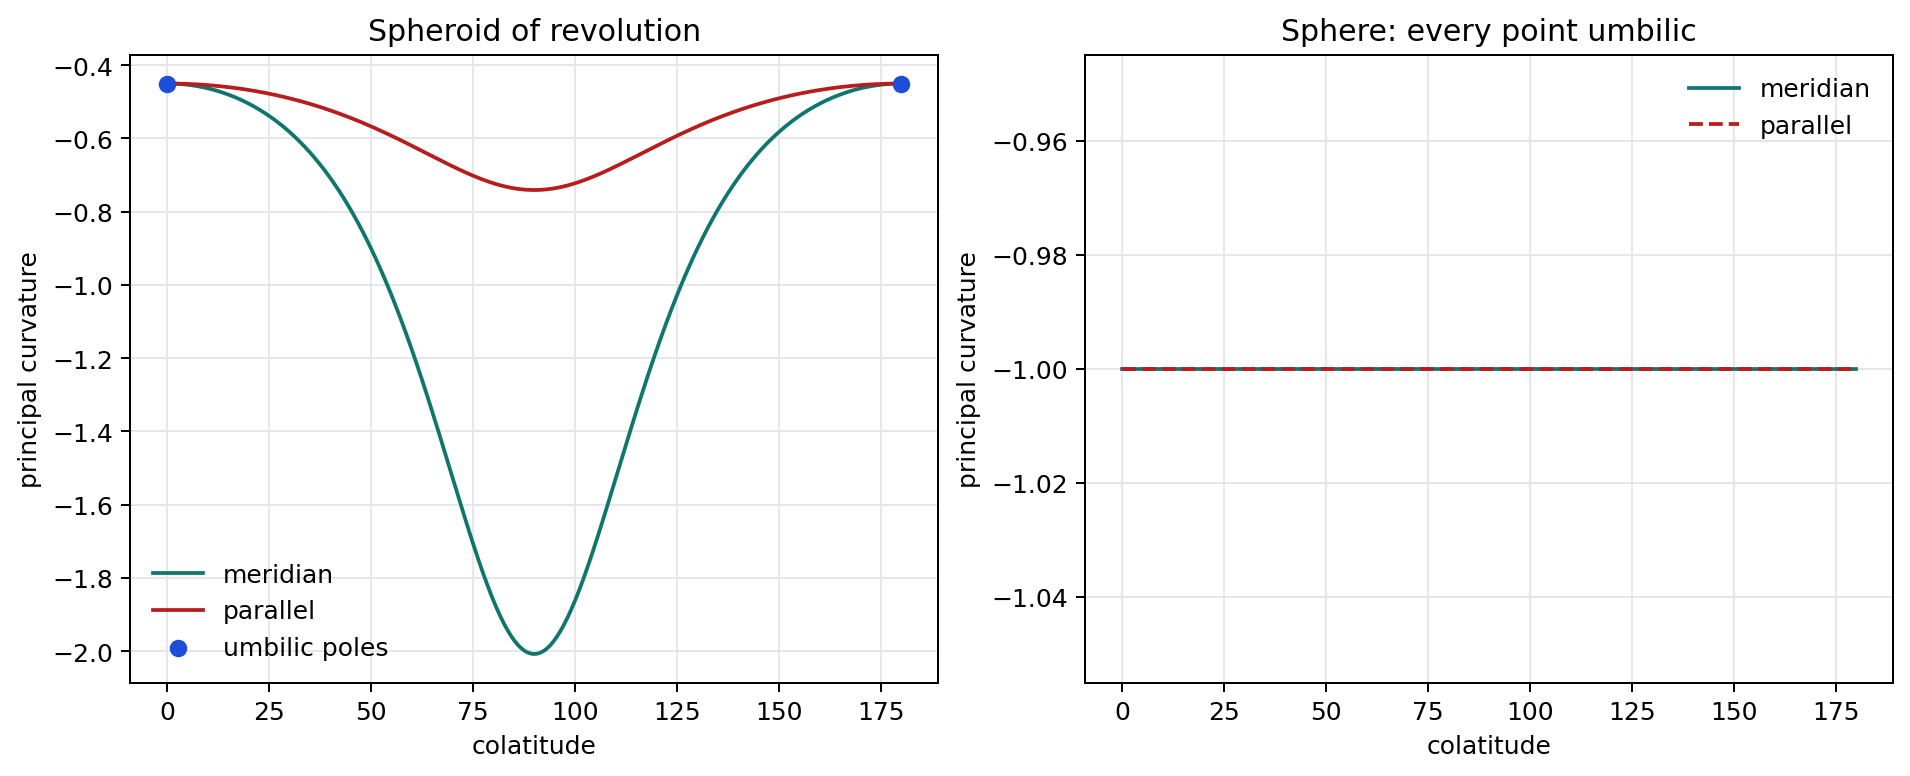

{'spheroid_pole_curvature': -0.44993141289437577,
 'north_pole_meridian_residual': 4.2589804460924086e-09,
 'north_pole_parallel_residual': 1.4196601116900354e-09,
 'sphere_max_curvature_gap': 4.440892098500626e-16,
 'ordinary_spheroid_max_gap': 1.2669616886735589}

In [6]:
def spheroid_curvatures(colatitude,a,c):
    E=a*a*np.cos(colatitude)**2+c*c*np.sin(colatitude)**2
    return -a*c/(E**1.5), -c/(a*np.sqrt(E))

uu=np.linspace(1e-4,np.pi-1e-4,600)
km,kp=spheroid_curvatures(uu,1.35,.82); sm,spv=spheroid_curvatures(uu,1.,1.)
fig,axes=plt.subplots(1,2,figsize=(10.5,4.2),constrained_layout=True)
ax=axes[0]; ax.plot(np.degrees(uu),km,color="#0f766e",label="meridian"); ax.plot(np.degrees(uu),kp,color="#b91c1c",label="parallel"); pole=-.82/(1.35**2); ax.scatter([0,180],[pole,pole],color="#1d4ed8",zorder=3,label="umbilic poles"); ax.set_title("Spheroid of revolution"); ax.set_xlabel("colatitude"); ax.set_ylabel("principal curvature"); ax.grid(True,color="#e5e7eb"); ax.legend(frameon=False)
ax=axes[1]; ax.plot(np.degrees(uu),sm,color="#0f766e",label="meridian"); ax.plot(np.degrees(uu),spv,color="#b91c1c",ls="--",label="parallel"); ax.set_title("Sphere: every point umbilic"); ax.set_xlabel("colatitude"); ax.set_ylabel("principal curvature"); ax.grid(True,color="#e5e7eb"); ax.legend(frameon=False)
umbilic_png=artifact_path(CHAPTER_NO,"figures","umbilic-surface-of-revolution-curvatures.png",BOOK_ROOT)
fig.savefig(umbilic_png,bbox_inches="tight"); plt.close(fig)
umbilic_checks={"spheroid_pole_curvature":pole,"north_pole_meridian_residual":float(abs(km[0]-pole)),"north_pole_parallel_residual":float(abs(kp[0]-pole)),"sphere_max_curvature_gap":float(np.max(np.abs(sm-spv))),"ordinary_spheroid_max_gap":float(np.max(np.abs(km-kp)))}
assert umbilic_checks["north_pole_meridian_residual"]<1e-4 and umbilic_checks["north_pole_parallel_residual"]<1e-4
assert umbilic_checks["sphere_max_curvature_gap"]<1e-12 and umbilic_checks["ordinary_spheroid_max_gap"]>.1
display_artifact(umbilic_png,width=900)
umbilic_checks


## 5. Dupin's Theorem and Liouville's Theorem

Dupin's theorem says that three mutually orthogonal systems of surfaces cut lines of curvature on each other. Cylindrical coordinates give a concrete example: cylinders, radial half-planes, and horizontal planes meet orthogonally; on a cylinder, their intersections are the circular and vertical curvature lines.

Liouville's theorem says that an angle-preserving transformation of space preserves spheres, with planes counted as spheres through infinity. Inversion is the model non-similarity: it maps a plane not through the origin to a sphere and preserves sampled tangent angles.

The proof idea behind Dupin's theorem is compact. Mutual orthogonality gives $g_{12}=0$ on a chosen surface. Differentiating the orthogonality relation with respect to the third coordinate shows that the mixed second fundamental coefficient also vanishes. The criterion for curvature-line coordinates is exactly this pair of vanishings, so the intersections with the other two surface families must be principal curves.

Liouville's theorem uses a different but related observation. An angle-preserving map sends mutually orthogonal systems to mutually orthogonal systems, so it respects the curvature-line structure that Dupin identifies. Spheres and planes are characterized by the absence of a preferred principal direction: all tangent directions are principal. That characterization is what lets the chapter conclude sphere preservation from angle preservation.



In [7]:
R=1.; th=np.linspace(0,2*np.pi,96); z=np.linspace(-1.2,1.2,42); TH,ZZ=np.meshgrid(th,z,indexing="ij")
fig=go.Figure(); fig.add_surface(x=R*np.cos(TH),y=R*np.sin(TH),z=ZZ,opacity=.58,colorscale="Blues",showscale=False,name="cylinder r=R")
plane_theta=.75; rho=np.linspace(0,1.45,40); zz=np.linspace(-1.2,1.2,40); RR,PPZ=np.meshgrid(rho,zz,indexing="ij")
fig.add_surface(x=RR*np.cos(plane_theta),y=RR*np.sin(plane_theta),z=PPZ,opacity=.32,colorscale=[[0,"#f97316"],[1,"#f97316"]],showscale=False,name="theta plane")
RR2,TH2=np.meshgrid(np.linspace(0,1.45,40),np.linspace(0,2*np.pi,80),indexing="ij"); plane_z=.35
fig.add_surface(x=RR2*np.cos(TH2),y=RR2*np.sin(TH2),z=np.full_like(RR2,plane_z),opacity=.24,colorscale=[[0,"#22c55e"],[1,"#22c55e"]],showscale=False,name="z plane")
fig.add_trace(go.Scatter3d(x=R*np.cos(th),y=R*np.sin(th),z=np.full_like(th,plane_z),mode="lines",line=dict(color="#166534",width=8),name="circle curvature line"))
fig.add_trace(go.Scatter3d(x=np.full_like(z,R*np.cos(plane_theta)),y=np.full_like(z,R*np.sin(plane_theta)),z=z,mode="lines",line=dict(color="#c2410c",width=8),name="generator curvature line"))
fig.update_layout(title="Dupin theorem in cylindrical coordinates",scene=dict(aspectmode="data"),margin=dict(l=0,r=0,t=42,b=0))
dupin_html=artifact_path(CHAPTER_NO,"html","dupin-orthogonal-surface-systems.html",BOOK_ROOT); fig.write_html(dupin_html,include_plotlyjs="cdn")
rth=np.array([-R*math.sin(plane_theta),R*math.cos(plane_theta),0.]); rz=np.array([0.,0.,1.]); nc=np.array([math.cos(plane_theta),math.sin(plane_theta),0.]); rtt=np.array([-R*math.cos(plane_theta),-R*math.sin(plane_theta),0.])
G_cyl=np.array([[rth@rth,rth@rz],[rth@rz,rz@rz]]); B_cyl=np.array([[rtt@nc,0.],[0.,0.]])
_,cyl_vals,_=principal_data(G_cyl,B_cyl); dupin_checks={"G_cylinder":G_cyl.tolist(),"B_cylinder":B_cyl.tolist(),"g12":float(G_cyl[0,1]),"b12":float(B_cyl[0,1]),"principal_curvatures":cyl_vals.tolist()}
assert abs(dupin_checks["g12"])<1e-12 and abs(dupin_checks["b12"])<1e-12
display_artifact(dupin_html)
dupin_checks


{'G_cylinder': [[1.0, 0.0], [0.0, 1.0]],
 'B_cylinder': [[-1.0, 0.0], [0.0, 0.0]],
 'g12': 0.0,
 'b12': 0.0,
 'principal_curvatures': [-1.0, 0.0]}

In [8]:
def invert_points(P):
    return P/np.sum(P*P,axis=1,keepdims=True)
def inversion_derivative(x):
    n2=float(x@x); return (n2*np.eye(3)-2*np.outer(x,x))/(n2**2)

a_plane=1.15; sx=np.linspace(-1.15,1.15,42); sy=np.linspace(-1.15,1.15,42); SX,SY=np.meshgrid(sx,sy)
plane=np.c_[SX.ravel(),SY.ravel(),np.full(SX.size,a_plane)]; mapped=invert_points(plane); MX=mapped[:,0].reshape(SX.shape); MY=mapped[:,1].reshape(SX.shape); MZ=mapped[:,2].reshape(SX.shape)
center=np.array([0.,0.,1/(2*a_plane)]); radius=1/(2*a_plane); residual=np.abs(np.linalg.norm(mapped-center,axis=1)-radius)
fig=go.Figure(); fig.add_surface(x=SX,y=SY,z=np.full_like(SX,a_plane),opacity=.45,colorscale="Greens",showscale=False,name="plane z=a"); fig.add_surface(x=MX,y=MY,z=MZ,opacity=.72,colorscale="Purples",showscale=False,name="inverted sphere patch"); fig.add_trace(go.Scatter3d(x=[center[0]],y=[center[1]],z=[center[2]],mode="markers",marker=dict(size=4,color="#111827"),name="sphere center")); fig.update_layout(title="Liouville model: inversion maps a plane to a sphere",scene=dict(aspectmode="data"),margin=dict(l=0,r=0,t=42,b=0))
liouville_html=artifact_path(CHAPTER_NO,"html","liouville-inversion-plane-to-sphere.html",BOOK_ROOT); fig.write_html(liouville_html,include_plotlyjs="cdn")
x0=np.array([.42,-.31,a_plane]); D=inversion_derivative(x0); v1=np.array([1.,0.,0.]); v2=np.array([.35,1.,0.]); cb=float((v1@v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))); ca=float(((D@v1)@(D@v2))/(np.linalg.norm(D@v1)*np.linalg.norm(D@v2)))
liouville_checks={"plane_z":a_plane,"target_sphere_center":center.tolist(),"target_sphere_radius":radius,"max_sphere_residual":float(residual.max()),"angle_cos_before":cb,"angle_cos_after":ca,"angle_cos_residual":float(abs(cb-ca))}
assert liouville_checks["max_sphere_residual"]<1e-12 and liouville_checks["angle_cos_residual"]<1e-12
display_artifact(liouville_html)
liouville_checks


{'plane_z': 1.15,
 'target_sphere_center': [0.0, 0.0, 0.4347826086956522],
 'target_sphere_radius': 0.4347826086956522,
 'max_sphere_residual': 1.1102230246251565e-16,
 'angle_cos_before': 0.33035042472810605,
 'angle_cos_after': 0.33035042472810594,
 'angle_cos_residual': 1.1102230246251565e-16}

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\rahul\AppData\Local\Temp\ipykernel_3124\1047825957.py:1: SyntaxWarning: invalid escape sequence '\c'
  nodes=[("orthogonal surfaces","3 surface families\ncut at right angles"),("differentiate","differentiate $r_i\cdot r_j=0$"),("b12 zero","$b_{12}=n\cdot r_{12}=0$"),("criterion","$g_{12}=0$ and $b_{12}=0$"),("Dupin","intersections are\nlines of curvature"),("angle map","angle-preserving map\npreserves orthogonality"),("curvature lines","curvature lines\nmap to curvature lines"),("sphere criterion","all directions principal\nonly on plane/sphere"),("Liouville","angle-preserving maps\npreserve spheres")]
C:\Users\rahul\AppData\Local\Temp\ipykernel_3124\1047825957.py:1: SyntaxWarning: invalid escape sequence '\c'
  nodes=[("orthogonal surfaces","3 surface families\ncut at right angle

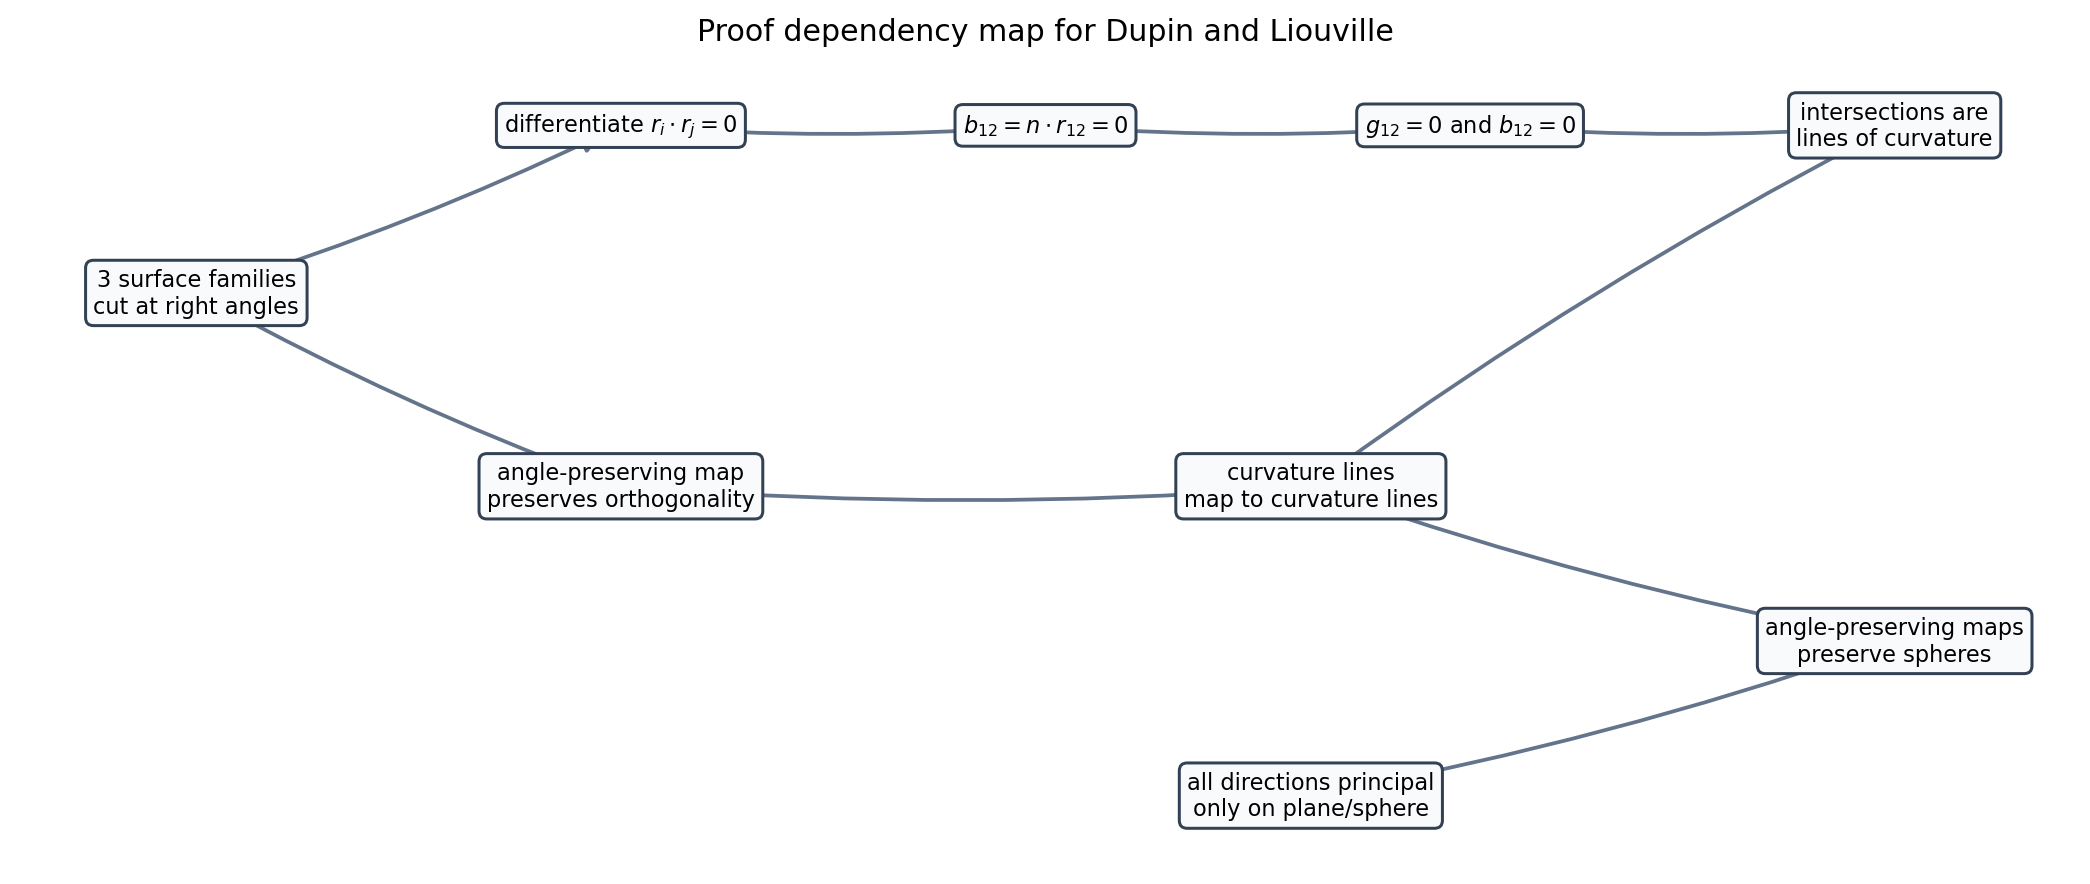

{'nodes': 9,
 'edges': 9,
 'is_dag': True,
 'topological_order': ['orthogonal surfaces',
  'sphere criterion',
  'differentiate',
  'angle map',
  'b12 zero',
  'criterion',
  'Dupin',
  'curvature lines',
  'Liouville']}

In [9]:
nodes=[("orthogonal surfaces","3 surface families\ncut at right angles"),("differentiate","differentiate $r_i\cdot r_j=0$"),("b12 zero","$b_{12}=n\cdot r_{12}=0$"),("criterion","$g_{12}=0$ and $b_{12}=0$"),("Dupin","intersections are\nlines of curvature"),("angle map","angle-preserving map\npreserves orthogonality"),("curvature lines","curvature lines\nmap to curvature lines"),("sphere criterion","all directions principal\nonly on plane/sphere"),("Liouville","angle-preserving maps\npreserve spheres")]
edges=[("orthogonal surfaces","differentiate"),("differentiate","b12 zero"),("b12 zero","criterion"),("criterion","Dupin"),("orthogonal surfaces","angle map"),("angle map","curvature lines"),("Dupin","curvature lines"),("sphere criterion","Liouville"),("curvature lines","Liouville")]
DG=nx.DiGraph(); DG.add_nodes_from([n for n,_ in nodes]); DG.add_edges_from(edges); assert nx.is_directed_acyclic_graph(DG)
pos={"orthogonal surfaces":(0,2),"differentiate":(1.6,2.65),"b12 zero":(3.2,2.65),"criterion":(4.8,2.65),"Dupin":(6.4,2.65),"angle map":(1.6,1.25),"curvature lines":(4.2,1.25),"sphere criterion":(4.2,.05),"Liouville":(6.4,.65)}; labels=dict(nodes)
fig,ax=plt.subplots(figsize=(11.5,4.8),constrained_layout=True); nx.draw_networkx_edges(DG,pos,ax=ax,arrows=True,arrowstyle="-|>",arrowsize=16,width=1.5,edge_color="#64748b",connectionstyle="arc3,rad=.04")
for node,(x,y) in pos.items(): ax.text(x,y,labels[node],ha="center",va="center",fontsize=9,bbox=dict(boxstyle="round,pad=.35",fc="#f8fafc",ec="#334155",lw=1.2))
ax.set_title("Proof dependency map for Dupin and Liouville"); ax.set_axis_off()
proof_png=artifact_path(CHAPTER_NO,"figures","dupin-liouville-proof-map.png",BOOK_ROOT); fig.savefig(proof_png,bbox_inches="tight"); plt.close(fig)
proof_checks={"nodes":len(DG.nodes),"edges":len(DG.edges),"is_dag":bool(nx.is_directed_acyclic_graph(DG)),"topological_order":list(nx.topological_sort(DG))}
display_artifact(proof_png,width=950)
proof_checks


## 6. Dupin's Indicatrix

In coordinates chosen so the tangent plane is $z=0$ and the normal is the $z$-axis, the second-order surface model is

$$2z=b_{11}x^2+2b_{12}xy+b_{22}y^2.$$

The conic $b_{11}x^2+2b_{12}xy+b_{22}y^2=\pm1$ is Dupin's indicatrix. In principal axes it gives Euler's formula $\kappa(\theta)=\kappa_1\cos^2\theta+\kappa_2\sin^2\theta$, and the indicatrix radius satisfies $r=|\kappa(\theta)|^{-1/2}$ where $\kappa\ne0$.

The indicatrix is useful because it compresses all normal curvatures at one point into a single tangent-plane picture. An ellipse means both principal curvatures have the same sign. A pair of conjugate hyperbolas means the principal curvatures have opposite signs and the asymptotes point toward zero normal curvature directions. A pair of parallel lines is the parabolic boundary case. The radius identity $r=|\kappa|^{-1/2}$ explains why the conic is not decorative: measuring a radius in a direction recovers the curvature of the corresponding normal section.



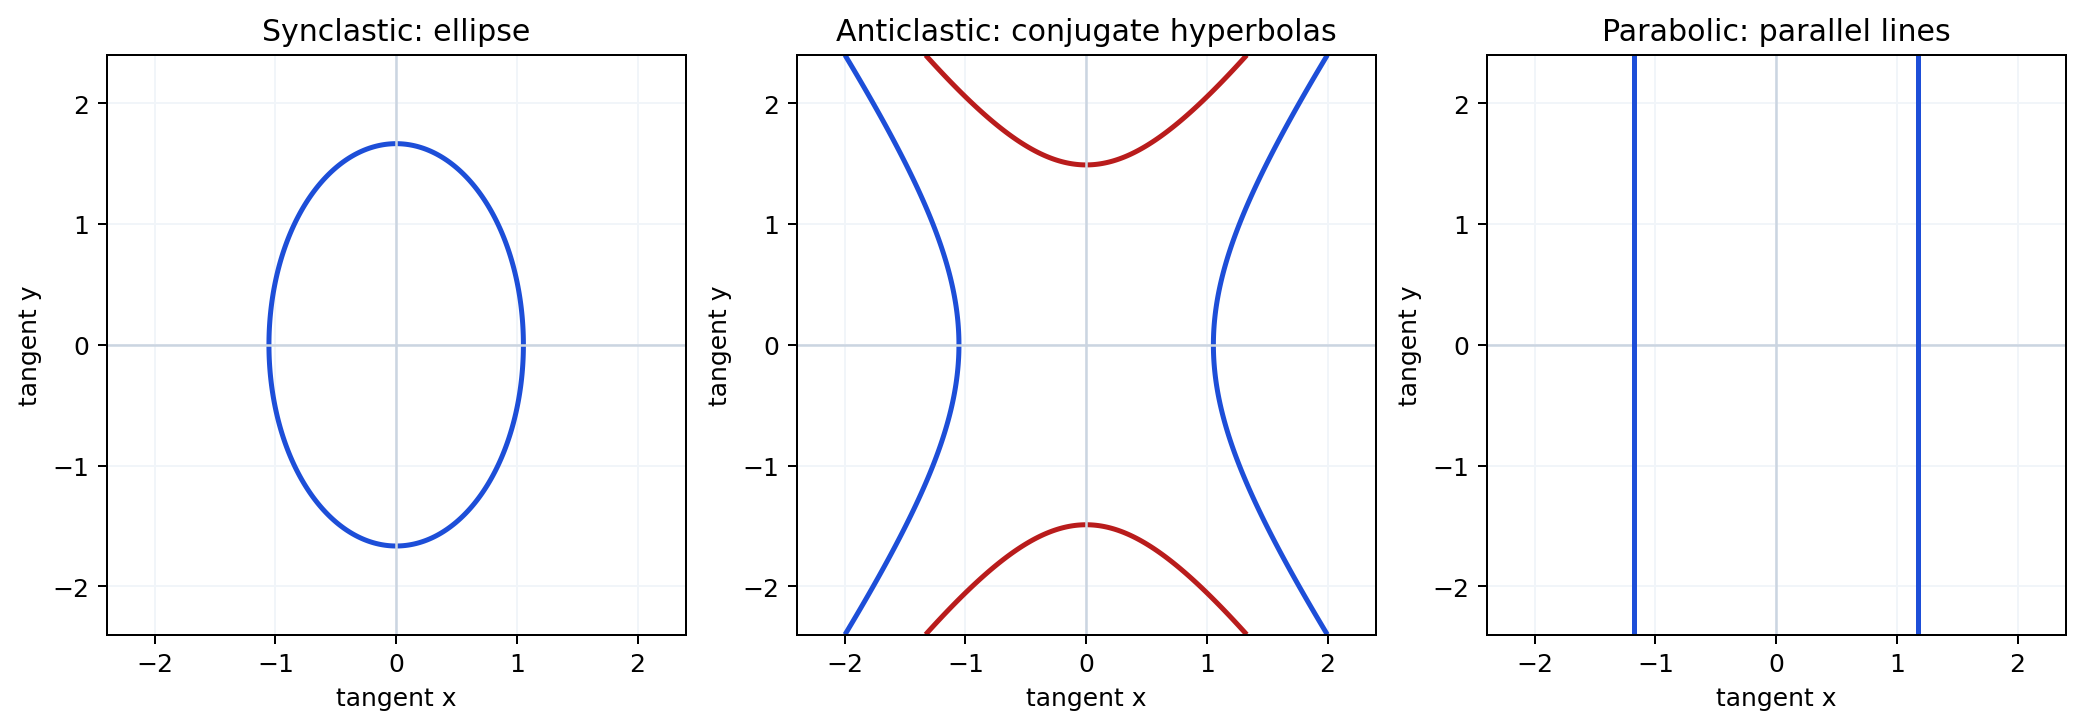

{'radius_identity_residuals': {'elliptic': 5.551115123125783e-16,
  'hyperbolic': 2.842170943040401e-14,
  'parabolic': 4.440892098500626e-16},
 'elliptic_det': 0.32399999999999995,
 'hyperbolic_det': -0.405,
 'parabolic_det': 0.0}

In [10]:
def conic(ax,Q,levels,title):
    xs=np.linspace(-2.4,2.4,520); ys=np.linspace(-2.4,2.4,520); Xg,Yg=np.meshgrid(xs,ys); Zq=Q[0,0]*Xg**2+2*Q[0,1]*Xg*Yg+Q[1,1]*Yg**2
    ax.contour(Xg,Yg,Zq,levels=levels,colors=["#b91c1c" if lev<0 else "#1d4ed8" for lev in levels],linewidths=2); ax.axhline(0,color="#cbd5e1",lw=1); ax.axvline(0,color="#cbd5e1",lw=1); ax.set_aspect("equal",adjustable="box"); ax.set_xlim(-2.4,2.4); ax.set_ylim(-2.4,2.4); ax.grid(True,color="#f1f5f9"); ax.set_title(title)
Qe=np.array([[.9,0.],[0.,.36]]); Qh=np.array([[.9,0.],[0.,-.45]]); Qp=np.array([[.72,0.],[0.,0.]])
fig,axes=plt.subplots(1,3,figsize=(11.5,3.8),constrained_layout=True); conic(axes[0],Qe,[1.],"Synclastic: ellipse"); conic(axes[1],Qh,[-1.,1.],"Anticlastic: conjugate hyperbolas")
axes[2].axhline(0,color="#cbd5e1",lw=1); axes[2].axvline(0,color="#cbd5e1",lw=1); xline=1/math.sqrt(Qp[0,0])
for s in [-1,1]: axes[2].plot([s*xline,s*xline],[-2.4,2.4],color="#1d4ed8",lw=2)
axes[2].set_aspect("equal",adjustable="box"); axes[2].set_xlim(-2.4,2.4); axes[2].set_ylim(-2.4,2.4); axes[2].grid(True,color="#f1f5f9"); axes[2].set_title("Parabolic: parallel lines")
for ax in axes: ax.set_xlabel("tangent x"); ax.set_ylabel("tangent y")
indicatrix_png=artifact_path(CHAPTER_NO,"figures","dupin-indicatrix-conics.png",BOOK_ROOT); fig.savefig(indicatrix_png,bbox_inches="tight"); plt.close(fig)
ang=np.linspace(.05,2*np.pi-.05,1000); residuals={}
for name,Q in [("elliptic",Qe),("hyperbolic",Qh),("parabolic",Qp)]:
    D=np.c_[np.cos(ang),np.sin(ang)]; kap=np.einsum("ij,jk,ik->i",D,Q,D); mask=np.abs(kap)>1e-3; rad=1/np.sqrt(np.abs(kap[mask])); pts=D[mask]*rad[:,None]; vals=np.einsum("ij,jk,ik->i",pts,Q,pts); residuals[name]=float(np.max(np.abs(np.abs(vals)-1)))
indicatrix_checks={"radius_identity_residuals":residuals,"elliptic_det":float(np.linalg.det(Qe)),"hyperbolic_det":float(np.linalg.det(Qh)),"parabolic_det":float(np.linalg.det(Qp))}
assert max(residuals.values())<1e-12 and indicatrix_checks["elliptic_det"]>0 and indicatrix_checks["hyperbolic_det"]<0 and abs(indicatrix_checks["parabolic_det"])<1e-14
display_artifact(indicatrix_png,width=950)
indicatrix_checks


## Applied Lab: Change the Local Quadratic Form

Change `trial_B` and rerun the cell. The eigenvalues are the principal curvatures, their product is $K$, and the sign of $K$ tells which local picture to expect.

The lab is deliberately local. It does not need a global surface equation, because every regular surface has a second-order model at a point. Changing `trial_B` is changing the local bending while keeping the tangent metric fixed. A positive determinant produces the oval case, a negative determinant produces a saddle case, and a zero determinant produces a parabolic case. The quantity $H^2-K$ is included because it equals one quarter of the squared difference of the principal curvatures, so it vanishes precisely at an umbilic.



In [11]:
trial_G=np.eye(2); trial_B=np.array([[.62,.24],[.24,-.18]])
trial_S,trial_vals,trial_dirs=principal_data(trial_G,trial_B); trial_K=float(np.linalg.det(trial_S)); trial_H=float(np.trace(trial_S)/2)
lab_summary={"trial_B":trial_B.tolist(),"principal_curvatures":trial_vals.tolist(),"H":trial_H,"K":trial_K,"classification":"synclastic" if trial_K>1e-12 else "anticlastic" if trial_K<-1e-12 else "parabolic/developable","H_squared_minus_K":float(trial_H**2-trial_K)}
assert lab_summary["H_squared_minus_K"]>=-1e-12
lab_summary


{'trial_B': [[0.62, 0.24], [0.24, -0.18]],
 'principal_curvatures': [-0.24647615158762404, 0.6864761515876241],
 'H': 0.22,
 'K': -0.16919999999999996,
 'classification': 'anticlastic',
 'H_squared_minus_K': 0.21759999999999996}

## Final Sanity Checks

The final cell asserts concept-specific identities, artifact integrity, and removal of stale generic scaffold artifacts.


In [12]:
records=[
    ("check","source span",source_span_path),("check","visual storyboard",storyboard_path),("html","two-parameter surface patch",patch_html),("figure","tangent-plane components",components_png),("figure","normal curvature principal directions",principal_png),("figure","Gaussian curvature signs",classification_png),("table","curvature samples",curvature_table),("figure","umbilic surface of revolution",umbilic_png),("html","Dupin orthogonal systems",dupin_html),("html","Liouville inversion",liouville_html),("figure","Dupin Liouville proof map",proof_png),("figure","Dupin indicatrix",indicatrix_png)]
paths=[p for _,_,p in records]
assert_artifacts(paths,min_bytes=100)
assert not any(p.exists() for p in STALE_ARTIFACTS), [str(p) for p in STALE_ARTIFACTS if p.exists()]

surface_invariants={"source_span":source_span,"sphere_patch":sphere_checks,"metric_components":metric_checks,"principal_curvatures":principal_checks,"classification":classification_checks,"umbilics":umbilic_checks,"dupin":dupin_checks,"liouville":liouville_checks,"proof_graph":proof_checks,"indicatrix":indicatrix_checks,"applied_lab":lab_summary}
invariants_path=write_json(artifact_path(CHAPTER_NO,"checks","surface-invariants.json",BOOK_ROOT),surface_invariants)
records.append(("check","surface invariant ledger",invariants_path)); assert_artifacts([invariants_path],min_bytes=100)
manifest_rows=[{"kind":k,"concept":c,"path":book_relative(p,BOOK_ROOT),"bytes":p.stat().st_size} for k,c,p in records]
manifest_path=write_csv(artifact_path(CHAPTER_NO,"tables","artifact_manifest.csv",BOOK_ROOT),manifest_rows); assert_artifacts([manifest_path],min_bytes=50)
visual_summary_payload={"chapter":CHAPTER_NO,"title":"Differential Geometry of Surfaces","source_span":source_span,"visuals":[book_relative(p,BOOK_ROOT) for k,c,p in records if k in {"figure","html"}],"tables":[book_relative(p,BOOK_ROOT) for k,c,p in records if k=="table"],"checks":[book_relative(p,BOOK_ROOT) for k,c,p in records if k=="check"]+[book_relative(invariants_path,BOOK_ROOT)]}
visual_summary_path=write_json(artifact_path(CHAPTER_NO,"checks","visual_summary.json",BOOK_ROOT),visual_summary_payload); assert_artifacts([visual_summary_path],min_bytes=100)
final_sanity={"chapter":CHAPTER_NO,"artifact_count":len(records)+1,"all_required_artifacts_nonempty":True,"stale_scaffold_artifacts_removed":True,"checks":{"sphere_area":str(area),"metric_inverse_residual":metric_checks["G_inverse_residual"],"principal_orthogonality":principal_checks["G_orthogonality_residual"],"dupin_g12":dupin_checks["g12"],"dupin_b12":dupin_checks["b12"],"liouville_sphere_residual":liouville_checks["max_sphere_residual"],"liouville_angle_residual":liouville_checks["angle_cos_residual"],"indicatrix_radius_residual_max":max(indicatrix_checks["radius_identity_residuals"].values())},"manifest":book_relative(manifest_path,BOOK_ROOT),"visual_summary":book_relative(visual_summary_path,BOOK_ROOT)}
final_sanity_path=write_json(artifact_path(CHAPTER_NO,"checks","final-sanity.json",BOOK_ROOT),final_sanity); assert_artifacts([final_sanity_path],min_bytes=100)
display(Markdown("### Artifact Manifest")); display(pd.DataFrame(manifest_rows)); display(Markdown(f"Final sanity ledger: `{book_relative(final_sanity_path, BOOK_ROOT)}`"))
final_sanity


### Artifact Manifest

,kind,concept,path,bytes
0,check,source span,artifacts/chapter-19/checks/source-span.json,447
1,check,visual storyboard,artifacts/chapter-19/checks/visual-storyboard....,796
2,html,two-parameter surface patch,artifacts/chapter-19/html/two-parameter-surfac...,274388
3,figure,tangent-plane components,artifacts/chapter-19/figures/tangent-plane-com...,90849
4,figure,normal curvature principal directions,artifacts/chapter-19/figures/normal-curvature-...,124739
5,figure,Gaussian curvature signs,artifacts/chapter-19/figures/gaussian-curvatur...,550390
6,table,curvature samples,artifacts/chapter-19/tables/curvature-samples.csv,393
7,figure,umbilic surface of revolution,artifacts/chapter-19/figures/umbilic-surface-o...,90881
8,html,Dupin orthogonal systems,artifacts/chapter-19/html/dupin-orthogonal-sur...,372134
9,html,Liouville inversion,artifacts/chapter-19/html/liouville-inversion-...,148964


Final sanity ledger: `artifacts/chapter-19/checks/final-sanity.json`

{'chapter': 19,
 'artifact_count': 14,
 'all_required_artifacts_nonempty': True,
 'stale_scaffold_artifacts_removed': True,
 'checks': {'sphere_area': '4*pi',
  'metric_inverse_residual': 1.1102230246251565e-16,
  'principal_orthogonality': 8.326672684688674e-17,
  'dupin_g12': 0.0,
  'dupin_b12': 0.0,
  'liouville_sphere_residual': 1.1102230246251565e-16,
  'liouville_angle_residual': 1.1102230246251565e-16,
  'indicatrix_radius_residual_max': 2.842170943040401e-14},
 'manifest': 'artifacts/chapter-19/tables/artifact_manifest.csv'}

## Takeaways

- A surface patch becomes measurable through $G=(g_{ij})$; the same determinant gives area scale and the length of $\mathbf{r}_1\times\mathbf{r}_2$.
- Normal curvature is the quotient of the second and first fundamental forms in a tangent direction.
- Principal curvatures are the two extremal normal curvatures, and their directions are perpendicular in the surface metric.
- $K=\det(B)/\det(G)$ separates synclastic, parabolic/developable, and anticlastic local behavior.
- Umbilics occur when the shape operator is scalar, so every direction is principal.
- Dupin's theorem turns mutually orthogonal surface systems into curvature-line systems; Liouville's theorem uses angle preservation to preserve spheres.
- Dupin's indicatrix is the tangent-plane conic form of Euler's normal-curvature formula.
